<div style='text-align:center; background:#1a1a2e; color:white; padding:28px; border-radius:12px; font-family:Arial,sans-serif;'>
<h1 style='color:#e94560; margin-bottom:4px;'>Actividad 4 — Almacenamiento y Procesamiento IoT</h1>
<h2 style='color:#fff; margin-top:0;'>TimescaleDB Cloud (Tiger Cloud)</h2>
<hr style='border-color:#e94560; margin:18px 0;'/>
<table style='margin:0 auto; font-size:15px; color:#ccc;'>
<tr><td style='padding:5px 18px; text-align:right; color:#e94560;'><b>Estudiante:</b></td><td style='padding:5px 18px;'>Ana María García Arias</td></tr>
<tr><td style='padding:5px 18px; text-align:right; color:#e94560;'><b>Programa:</b></td><td style='padding:5px 18px;'>Maestría en Inteligencia Artificial</td></tr>
<tr><td style='padding:5px 18px; text-align:right; color:#e94560;'><b>Docente:</b></td><td style='padding:5px 18px;'>Cristian Duney Bermúdez Quintero</td></tr>
<tr><td style='padding:5px 18px; text-align:right; color:#e94560;'><b>Fecha:</b></td><td style='padding:5px 18px;'>Mayo 2026</td></tr>
</table>
</div>

## 0. Configuración de conexión

Las credenciales se cargan desde `.env`. Nunca se exponen en el notebook.

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import psycopg2
from dotenv import load_dotenv

load_dotenv()

CONN_PARAMS = dict(
    host=os.environ['TS_HOST'],
    port=int(os.environ.get('TS_PORT', 33711)),
    dbname=os.environ.get('TS_DB', 'tsdb'),
    user=os.environ.get('TS_USER', 'tsdbadmin'),
    password=os.environ['TS_PASSWORD'],
    sslmode='require',
    connect_timeout=15,
)

def query(sql, params=None):
    with psycopg2.connect(**CONN_PARAMS) as conn:
        return pd.read_sql_query(sql, conn, params=params)

print('Conexion a TimescaleDB Cloud: OK')

Conexion a TimescaleDB Cloud: OK


---
## 1. Carga de datos desde la hypertable

In [2]:
df_raw = query("""
    SELECT ts AT TIME ZONE 'America/Bogota' AS ts_local,
           temperatura_c,
           humedad_pct,
           fuente
    FROM lecturas_iot
    ORDER BY ts;
""")

df_raw['ts_local'] = pd.to_datetime(df_raw['ts_local'])

print(f'Filas cargadas: {len(df_raw)}')
print(f'Periodo: {df_raw["ts_local"].min()}  a  {df_raw["ts_local"].max()}')
print(f'Fuentes: {df_raw["fuente"].value_counts().to_dict()}')
df_raw.head(10)

Filas cargadas: 20
Periodo: 2026-05-24 15:01:53.504640  a  2026-05-24 15:02:17.644716
Fuentes: {'simulate': 20}


,ts_local,temperatura_c,humedad_pct,fuente
0,2026-05-24 15:01:53.504640,23.14,62.78,simulate
1,2026-05-24 15:01:54.781185,21.12,54.08,simulate
2,2026-05-24 15:01:56.050629,24.46,69.28,simulate
3,2026-05-24 15:01:57.319537,23.91,61.24,simulate
4,2026-05-24 15:01:58.587643,23.74,58.45,simulate
5,2026-05-24 15:01:59.857279,24.05,62.12,simulate
6,2026-05-24 15:02:01.125678,27.83,59.02,simulate
7,2026-05-24 15:02:02.394772,24.55,55.04,simulate
8,2026-05-24 15:02:03.666212,21.63,57.08,simulate
9,2026-05-24 15:02:04.935531,24.88,60.75,simulate


---
## 2. Preprocesamiento

### 2.1 Verificación de nulos y duplicados

In [3]:
print('=== Valores nulos por columna ===')
print(df_raw.isnull().sum())

print(f'\nFilas duplicadas: {df_raw.duplicated().sum()}')

# Eliminar duplicados si existen
df = df_raw.drop_duplicates().copy()
print(f'Filas tras eliminar duplicados: {len(df)}')

=== Valores nulos por columna ===
ts_local         0
temperatura_c    0
humedad_pct      0
fuente           0
dtype: int64

Filas duplicadas: 0
Filas tras eliminar duplicados: 20


### 2.2 Detección de valores fuera de rango

Rangos válidos configurados en CounterFit:
- Temperatura: 18 – 35 °C
- Humedad: 40 – 90 %

In [4]:
T_MIN, T_MAX = 17.0, 36.0   # margen ±1 por redondeo del sensor
H_MIN, H_MAX = 33.0, 94.0

anomalias_t = df[(df['temperatura_c'] < T_MIN) | (df['temperatura_c'] > T_MAX)]
anomalias_h = df[(df['humedad_pct']   < H_MIN) | (df['humedad_pct']   > H_MAX)]

print(f'Anomalias de temperatura (fuera de {T_MIN}-{T_MAX} C): {len(anomalias_t)}')
print(f'Anomalias de humedad    (fuera de {H_MIN}-{H_MAX} %): {len(anomalias_h)}')

if len(anomalias_t) > 0:
    display(anomalias_t)
if len(anomalias_h) > 0:
    display(anomalias_h)

Anomalias de temperatura (fuera de 17.0-36.0 C): 0
Anomalias de humedad    (fuera de 33.0-94.0 %): 0


### 2.3 Estadísticas descriptivas del dataset limpio

In [5]:
stats = df[['temperatura_c', 'humedad_pct']].describe().round(3)
stats.index.name = 'Estadístico'
stats.columns = ['Temperatura (°C)', 'Humedad (%)']
display(stats)

,Temperatura (°C),Humedad (%)
Estadístico,,
count,20.000,20.000
mean,23.909,59.487
std,1.722,4.514
min,21.120,52.130
25%,23.012,56.758
50%,23.835,59.410
75%,24.915,61.278
max,27.830,69.280


---
## 3. Filtrado

### 3.1 Filtrado por ventana de tiempo (última hora)

TimescaleDB ejecuta este filtro directamente en la hypertable, aprovechando la partición por tiempo.

In [6]:
df_ultima_hora = query("""
    SELECT ts AT TIME ZONE 'America/Bogota' AS ts_local,
           temperatura_c,
           humedad_pct
    FROM lecturas_iot
    WHERE ts >= NOW() - INTERVAL '1 hour'
    ORDER BY ts;
""")

print(f'Lecturas en la ultima hora: {len(df_ultima_hora)}')
df_ultima_hora.head()

Lecturas en la ultima hora: 20


,ts_local,temperatura_c,humedad_pct
0,2026-05-24 15:01:53.504640,23.14,62.78
1,2026-05-24 15:01:54.781185,21.12,54.08
2,2026-05-24 15:01:56.050629,24.46,69.28
3,2026-05-24 15:01:57.319537,23.91,61.24
4,2026-05-24 15:01:58.587643,23.74,58.45


### 3.2 Filtrado por umbral de alerta

Identifica lecturas con temperatura > 27 °C o humedad > 75 % (condiciones de alerta ambiental).

In [7]:
df_alertas = df[(df['temperatura_c'] > 27) | (df['humedad_pct'] > 75)].copy()

print(f'Lecturas en condicion de alerta: {len(df_alertas)} de {len(df)} ({100*len(df_alertas)/len(df):.1f}%)')

if len(df_alertas) > 0:
    display(df_alertas.head(10))

Lecturas en condicion de alerta: 1 de 20 (5.0%)


,ts_local,temperatura_c,humedad_pct,fuente
6,2026-05-24 15:02:01.125678,27.83,59.02,simulate


### 3.3 Filtrado nativo con `time_bucket()` — agregados por hora

Función exclusiva de TimescaleDB: particiona el tiempo en cubos (buckets) y agrega directamente en la base de datos.

In [8]:
df_por_hora = query("""
    SELECT
        time_bucket('1 hour', ts) AT TIME ZONE 'America/Bogota' AS hora,
        ROUND(AVG(temperatura_c)::numeric, 2) AS temp_promedio,
        ROUND(MIN(temperatura_c)::numeric, 2) AS temp_min,
        ROUND(MAX(temperatura_c)::numeric, 2) AS temp_max,
        ROUND(AVG(humedad_pct)::numeric, 2)   AS hum_promedio,
        COUNT(*) AS n_lecturas
    FROM lecturas_iot
    GROUP BY hora
    ORDER BY hora;
""")

print(f'Cubos horarios: {len(df_por_hora)}')
display(df_por_hora)

Cubos horarios: 1


,hora,temp_promedio,temp_min,temp_max,hum_promedio,n_lecturas
0,2026-05-24 15:00:00,23.91,21.12,27.83,59.49,20


---
## 4. Transformación

### 4.1 Promedio móvil (suavizado de ruido)

In [9]:
VENTANA = 5

df['temp_rolling'] = df['temperatura_c'].rolling(window=VENTANA, center=True).mean()
df['hum_rolling']  = df['humedad_pct'].rolling(window=VENTANA, center=True).mean()

print(f'Promedio movil calculado con ventana de {VENTANA} muestras.')
df[['ts_local', 'temperatura_c', 'temp_rolling', 'humedad_pct', 'hum_rolling']].head(10)

Promedio movil calculado con ventana de 5 muestras.


,ts_local,temperatura_c,temp_rolling,humedad_pct,hum_rolling
0,2026-05-24 15:01:53.504640,23.14,NaN,62.78,NaN
1,2026-05-24 15:01:54.781185,21.12,NaN,54.08,NaN
2,2026-05-24 15:01:56.050629,24.46,23.274,69.28,61.166
3,2026-05-24 15:01:57.319537,23.91,23.456,61.24,61.034
4,2026-05-24 15:01:58.587643,23.74,24.798,58.45,62.022
5,2026-05-24 15:01:59.857279,24.05,24.816,62.12,59.174
6,2026-05-24 15:02:01.125678,27.83,24.360,59.02,58.342
7,2026-05-24 15:02:02.394772,24.55,24.588,55.04,58.802
8,2026-05-24 15:02:03.666212,21.63,24.404,57.08,58.290
9,2026-05-24 15:02:04.935531,24.88,23.882,60.75,57.644


### 4.2 Normalización min-max [0, 1]

In [10]:
df['temp_norm'] = (df['temperatura_c'] - df['temperatura_c'].min()) / \
                  (df['temperatura_c'].max() - df['temperatura_c'].min())

df['hum_norm']  = (df['humedad_pct'] - df['humedad_pct'].min()) / \
                  (df['humedad_pct'].max() - df['humedad_pct'].min())

print('Normalizacion min-max aplicada.')
print(f'temp_norm: min={df["temp_norm"].min():.3f}  max={df["temp_norm"].max():.3f}')
print(f'hum_norm:  min={df["hum_norm"].min():.3f}  max={df["hum_norm"].max():.3f}')

Normalizacion min-max aplicada.
temp_norm: min=0.000  max=1.000
hum_norm:  min=0.000  max=1.000


### 4.3 Agregados diarios con `time_bucket()` — 24 horas

In [11]:
df_diario = query("""
    SELECT
        time_bucket('1 day', ts) AT TIME ZONE 'America/Bogota' AS dia,
        ROUND(AVG(temperatura_c)::numeric, 2) AS temp_prom,
        ROUND(STDDEV(temperatura_c)::numeric, 3) AS temp_std,
        ROUND(AVG(humedad_pct)::numeric, 2)   AS hum_prom,
        ROUND(STDDEV(humedad_pct)::numeric, 3) AS hum_std,
        COUNT(*) AS n
    FROM lecturas_iot
    GROUP BY dia
    ORDER BY dia;
""")

display(df_diario)

,dia,temp_prom,temp_std,hum_prom,hum_std,n
0,2026-05-23 19:00:00,23.91,1.722,59.49,4.514,20


---
## 5. Visualización de resultados

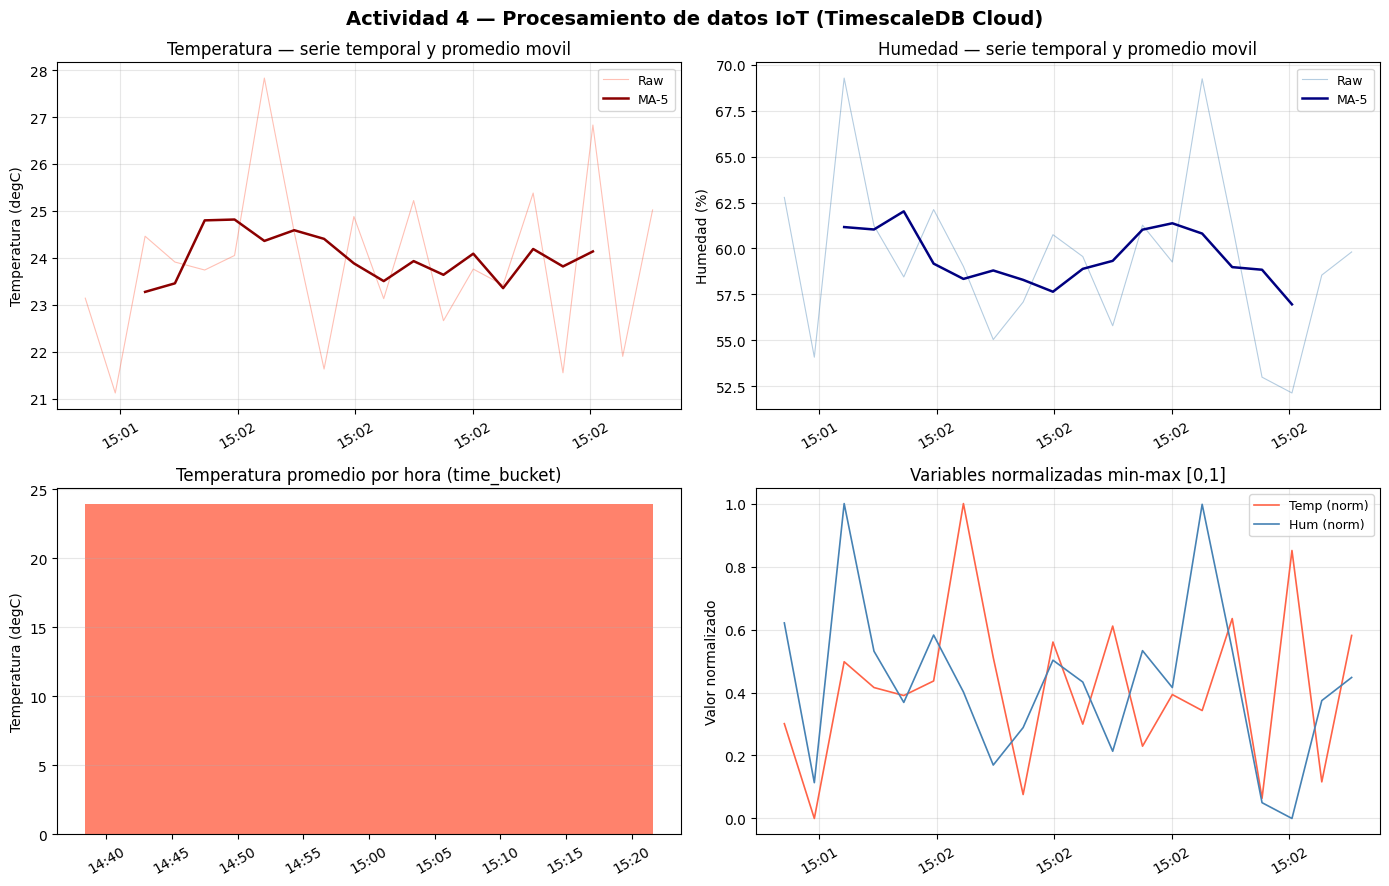

Figura guardada: figuras_actividad4.png


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Actividad 4 — Procesamiento de datos IoT (TimescaleDB Cloud)', fontsize=14, fontweight='bold')

# 1) Serie temporal temperatura con promedio movil
ax = axes[0, 0]
ax.plot(df['ts_local'], df['temperatura_c'], alpha=0.4, color='tomato', linewidth=0.8, label='Raw')
ax.plot(df['ts_local'], df['temp_rolling'], color='darkred', linewidth=1.8, label=f'MA-{VENTANA}')
ax.set_title('Temperatura — serie temporal y promedio movil')
ax.set_ylabel('Temperatura (degC)')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.tick_params(axis='x', rotation=30)
ax.grid(alpha=0.3)

# 2) Serie temporal humedad con promedio movil
ax = axes[0, 1]
ax.plot(df['ts_local'], df['humedad_pct'], alpha=0.4, color='steelblue', linewidth=0.8, label='Raw')
ax.plot(df['ts_local'], df['hum_rolling'], color='navy', linewidth=1.8, label=f'MA-{VENTANA}')
ax.set_title('Humedad — serie temporal y promedio movil')
ax.set_ylabel('Humedad (%)')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.tick_params(axis='x', rotation=30)
ax.grid(alpha=0.3)

# 3) Agregados por hora (time_bucket)
ax = axes[1, 0]
if len(df_por_hora) > 0:
    horas = pd.to_datetime(df_por_hora['hora'])
    ax.bar(horas, df_por_hora['temp_promedio'], width=0.03, color='tomato', alpha=0.8, label='Temp prom/hora')
    ax.set_title('Temperatura promedio por hora (time_bucket)')
    ax.set_ylabel('Temperatura (degC)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.tick_params(axis='x', rotation=30)
    ax.grid(alpha=0.3, axis='y')
else:
    ax.text(0.5, 0.5, 'Sin datos por hora aun', ha='center', va='center', transform=ax.transAxes)
    ax.set_title('Temperatura promedio por hora')

# 4) Valores normalizados
ax = axes[1, 1]
ax.plot(df['ts_local'], df['temp_norm'], color='tomato', linewidth=1.2, label='Temp (norm)')
ax.plot(df['ts_local'], df['hum_norm'],  color='steelblue', linewidth=1.2, label='Hum (norm)')
ax.set_title('Variables normalizadas min-max [0,1]')
ax.set_ylabel('Valor normalizado')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.tick_params(axis='x', rotation=30)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('figuras_actividad4.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: figuras_actividad4.png')

---
## 6. Resumen del pipeline de procesamiento

In [13]:
print('=' * 60)
print('RESUMEN — Pipeline de procesamiento IoT (Actividad 4)')
print('=' * 60)
print(f'  Infraestructura  : TimescaleDB Cloud (Tiger Cloud) v2.27')
print(f'  Total filas raw  : {len(df_raw)}')
print(f'  Tras preproceso  : {len(df)}')
print(f'  Alertas (T>27 | HR>75) : {len(df_alertas)} ({100*len(df_alertas)/max(len(df),1):.1f}%)')
print(f'  Cubos horarios   : {len(df_por_hora)}')
print(f'  Cubos diarios    : {len(df_diario)}')
print()
print('  Etapas aplicadas:')
print('  [1] Preprocesamiento : nulos, duplicados, anomalias de rango')
print('  [2] Filtrado         : ventana temporal, umbral de alerta, time_bucket()')
print('  [3] Transformacion   : promedio movil (MA-5), normalizacion min-max,')
print('                         agregados horarios y diarios con time_bucket()')
print('=' * 60)

RESUMEN — Pipeline de procesamiento IoT (Actividad 4)
  Infraestructura  : TimescaleDB Cloud (Tiger Cloud) v2.27
  Total filas raw  : 20
  Tras preproceso  : 20
  Alertas (T>27 | HR>75) : 1 (5.0%)
  Cubos horarios   : 1
  Cubos diarios    : 1

  Etapas aplicadas:
  [1] Preprocesamiento : nulos, duplicados, anomalias de rango
  [2] Filtrado         : ventana temporal, umbral de alerta, time_bucket()
  [3] Transformacion   : promedio movil (MA-5), normalizacion min-max,
                         agregados horarios y diarios con time_bucket()
